In [1]:
from scipy.fft import fft

import numpy as np
from matplotlib import pyplot as plt
%config InlineBackend.figure_formats = ['svg']

import IPython.display as ipd


from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


In [2]:
# 1000 Hz sampling rate
fs = 48000

# time vector with N samples length
N  = 2*fs
t  = np.linspace(0,N,N)/fs

f0 = 200

Nsteps = 8

x  = np.sin(2*np.pi*f0*t)
#x  = 2*(np.random.random(N)-0.5)
y  = np.zeros(N)
e  = np.zeros(N)

vals  = np.linspace(-0.9,0.9,Nsteps)
steps = np.linspace(-1,1,Nsteps)




-----

# 3-Bit Sine Sampling

The following example quantizes a sine wave with 3 bit.
This bit-depth is too low to result in acceptable results, but it is well suited for demonstrating the effects that occur during quantization.
The sine wave has an amplitude of $1$, a frequency of $f=200 \mathrm{Hz}$ at a sampling rate of $f=48 \mathrm{kHz}$:



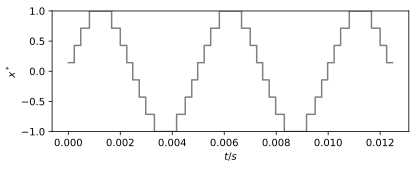

In [3]:
## Loop over all samples of x
for idx in range(N):
    i = np.abs(steps-x[idx]).argmin()
    y[idx] = steps[i]
    e[idx] = y[idx] - x[idx]

fig = plt.figure()
ax = fig.add_subplot(2, 1, 1)
ax.set_ylim(-1, 1)    

line1, = ax.step(t[0:3*f0], y[0:3*f0], color = [0.5,0.5,0.5])
plt.xlabel('$t / s$')
plt.ylabel('$x^*$'); 

-----

# Audio Results

Original sine wave with $f_0 = 200 \mathrm{Hz}$:

In [4]:
ipd.Audio(x, rate=fs)

 

Quantized sine wave at 16 kHz:

In [5]:

ipd.Audio(y, rate=fs)


At 3 bit, the quantized sine wave is heavily distorted.
The distortions are apparantly harmonic.


------

# Quantization Error

The quantization error $e$ is the difference between the input signal and the quantized signal:

$$
e = x-x*
$$



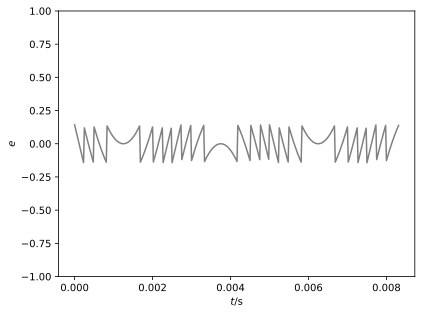

In [6]:
fig = plt.figure()
ax2 = fig.add_subplot(1, 1, 1)
ax2.set_ylim(-1, 1)    
line1, = ax2.plot(t[0:2*f0], e[0:2*f0], color = [0.5,0.5,0.5])
plt.xlabel('$t / \mathrm{s}$')
plt.ylabel('$e$'); 
 

-----

# PDF

The PDF of the quantization error is Laplace shaped:

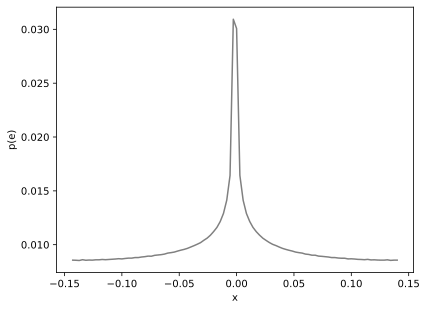

In [7]:
pp,xx = np.histogram(e,bins=100);
plt.plot(xx[0:-1],pp/sum(pp),'gray')
plt.xlabel('x');
plt.ylabel('p(e)');


----

# Spectrum

The magintude spectrum clearly shows the harmonic nature of the distortion, 
with peaks at integer multiples of the input signal's frequency $f_0=200$.


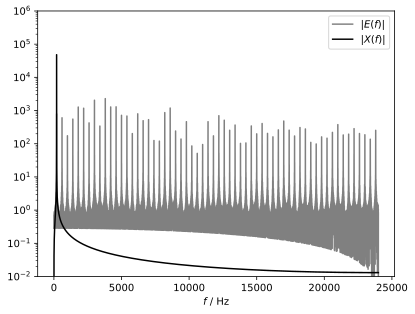

In [8]:

fig,ax = plt.subplots()

E = fft(e)[0:int(N/2)]
X = fft(x)[0:int(N/2)]
f = np.linspace(0,fs/2,int(N/2))

plt.plot(f,abs(E),'gray')
plt.plot(f,abs(X),'k')

ax.set_yscale('log')
ax.set_ylim([0.01,10e5])
plt.legend(['$|E(f)|$','$|X(f)|$'])
plt.xlabel('$f $ / Hz');
